In [69]:
import os
import pandas as pd
import numpy as np
import kagglehub
import shutil
import matplotlib.pylab as plt
import seaborn as sns
from rich import print as rprint
# Download latest version
path_to_move = os.path.join(os.path.dirname(os.path.abspath('')), "../","data/mv-lens-1m")
if not os.path.exists(path_to_move):
    path = kagglehub.dataset_download("odedgolden/movielens-1m-dataset")
    shutil.move(path , path_to_move)
    rprint("File moved to data folder!")


In [70]:
data_path = os.path.join(os.path.abspath('') , '../../' , "data/mv-lens-1m")
ratings_path = data_path + "/ratings.dat"
movies_path = data_path + "/movies.dat"
users_path = data_path + "/users.dat"



# Reading Files

In [71]:
# rating
rnames = ['user_id', 'movie_id', 'rating', 'timestamp']
rating_df = pd.read_csv(ratings_path , delimiter="::" , engine="python" ,encoding='latin-1', header=None , names=rnames)
# movies
mnames = ['movie_id', 'title', 'genres']
movie_df = pd.read_table(movies_path , delimiter="::" , engine="python" , header=None , encoding='latin-1' ,  names=mnames)
# users    
unames = ['user_id', 'gender', 'age', 'occupation', 'zip']
user_df = pd.read_table(users_path , delimiter="::" , engine="python" , header=None , encoding='latin-1' ,  names=unames)


# Caluclate sparsity and density
### Density
Density = (Number of observed ratings) / (Number of users × Number of items)

### Sparsity
Sparsity = 1 − Density

	​


In [72]:
total_users = rating_df['user_id'].nunique()
total_movies = rating_df['movie_id'].nunique()
total_ratings = len(rating_df)

# Calculating density of rating
density = total_ratings / (total_users * total_movies)
rprint(f"[green] Density: {density}")
# Calculating Sparsity of rating
sparsity = 1 - density
rprint(f"[red] Sparsity: {sparsity}")

 Density: 0.044683625622312845

 Sparsity: 0.9553163743776871

### Merge movies with rating to perform basic EDA

In [73]:
merged_df = rating_df.merge(movie_df , on='movie_id' , how='left')
merged_df.head()

,user_id,movie_id,rating,timestamp,title,genres
0,1,1193,5,978300760,One Flew Over the Cuckoo's Nest (1975),Drama
1,1,661,3,978302109,James and the Giant Peach (1996),Animation|Children's|Musical
2,1,914,3,978301968,My Fair Lady (1964),Musical|Romance
3,1,3408,4,978300275,Erin Brockovich (2000),Drama
4,1,2355,5,978824291,"Bug's Life, A (1998)",Animation|Children's|Comedy


ValueError: The number of FixedLocator locations (1), usually from a call to set_ticks, does not match the number of labels (20).

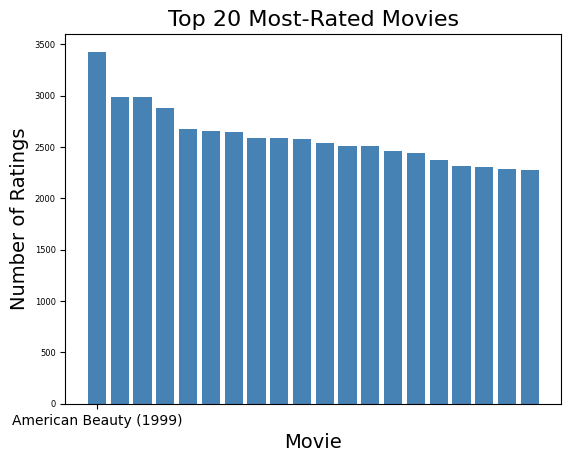

In [ ]:
# Top 20 movies according to most ratings
movie_stats = merged_df.groupby(['movie_id', 'title'])['rating'].count().sort_values(ascending=False).reset_index(name="rating")
top20_df = movie_stats[:20]

fig , ax = plt.subplots()
ax.bar(top20_df['title'], top20_df['rating'], color='steelblue')
ax.set_title('Top 20 Most-Rated Movies', fontsize=16)
ax.set_xlabel('Movie', fontsize=14)
ax.set_ylabel('Number of Ratings', fontsize=14)
ax.tick_params(axis='y', labelsize=6)
ax.set_xticks(range(len(top20_df['title'])))
ax.set_xticklabels(top20_df['title'], rotation=60, ha='right', fontsize=8)    

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()